## SHAP Explainability & Business Impact

**Goal:** Explain the final saved XGBoost fraud model globally and locally, save presentation-ready plots, and translate the locked operating point into business terms. This notebook is read-only with respect to modeling: it does not retrain the model or reselect the threshold.

Run after Notebook 04.

### 1. Setup & Load Final Artifacts

We use the persisted XGBoost model, untouched test data, and the validation-selected threshold from Notebook 04. SHAP values are computed on a reproducible test sample for the global plot and on three selected test transactions for local explanations.

In [1]:
from pathlib import Path
import builtins
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# The optional PyTorch DLL cannot initialize in this environment. SHAP 0.44 imports it
# for image explainers even though this notebook uses only TreeExplainer. Hide it during import.
_original_import = builtins.__import__
def _no_torch_import(name, *args, **kwargs):
    if name == 'torch' or name.startswith('torch.'):
        raise ImportError('PyTorch is intentionally unavailable for tree-only SHAP.')
    return _original_import(name, *args, **kwargs)
builtins.__import__ = _no_torch_import
try:
    import shap
finally:
    builtins.__import__ = _original_import
from IPython.display import Markdown, display
from sklearn.metrics import precision_score, recall_score

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
OPERATING_THRESHOLD = 0.053649693727493286  # selected on validation data in Notebook 04
SHAP_SAMPLE_SIZE = 1_000

ARTIFACT_DIR = Path('../reports/artifacts/shap')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

X_test = pd.read_parquet('../data/processed/X_test_enhanced.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze().astype(int)
model = joblib.load('../models/xgb_model.pkl')

assert X_test.columns.tolist() == list(model.feature_names_in_), 'Model and test feature order do not match.'
print(f'Test data: {X_test.shape[0]:,} rows x {X_test.shape[1]} features')
print(f'Operating threshold locked from validation: {OPERATING_THRESHOLD:.4f}')
print(f'SHAP images will be saved to: {ARTIFACT_DIR.resolve()}')

Test data: 118,108 rows x 62 features
Operating threshold locked from validation: 0.0536
SHAP images will be saved to: D:\p1-fraud-detection\reports\artifacts\shap


### 2. Reproduce the Final Operating Point

This is an audit check only. The threshold remains fixed before this test evaluation.

In [2]:
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= OPERATING_THRESHOLD).astype(int)
recall = recall_score(y_test, test_pred)
precision = precision_score(y_test, test_pred, zero_division=0)
flag_rate = test_pred.mean()
avg_fraud_amt = X_test.loc[y_test.eq(1), 'TransactionAmt'].mean()

print(f'Test recall: {recall:.4%}')
print(f'Test precision: {precision:.4%}')
print(f'Alert / review rate: {flag_rate:.4%}')
print(f'Average fraud transaction amount: ${avg_fraud_amt:,.2f}')

Test recall: 91.1686%
Test precision: 11.0869%
Alert / review rate: 28.7754%
Average fraud transaction amount: $153.09


### 3. Global SHAP: Top 20 Drivers

TreeExplainer reports feature contributions to the model's raw score (log-odds). Each dot is a transaction; position shows whether the feature pushed the prediction toward fraud (right) or legitimate (left), and color shows the feature value. The sample is stratified so both fraud and legitimate behavior are represented.

[22:30:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


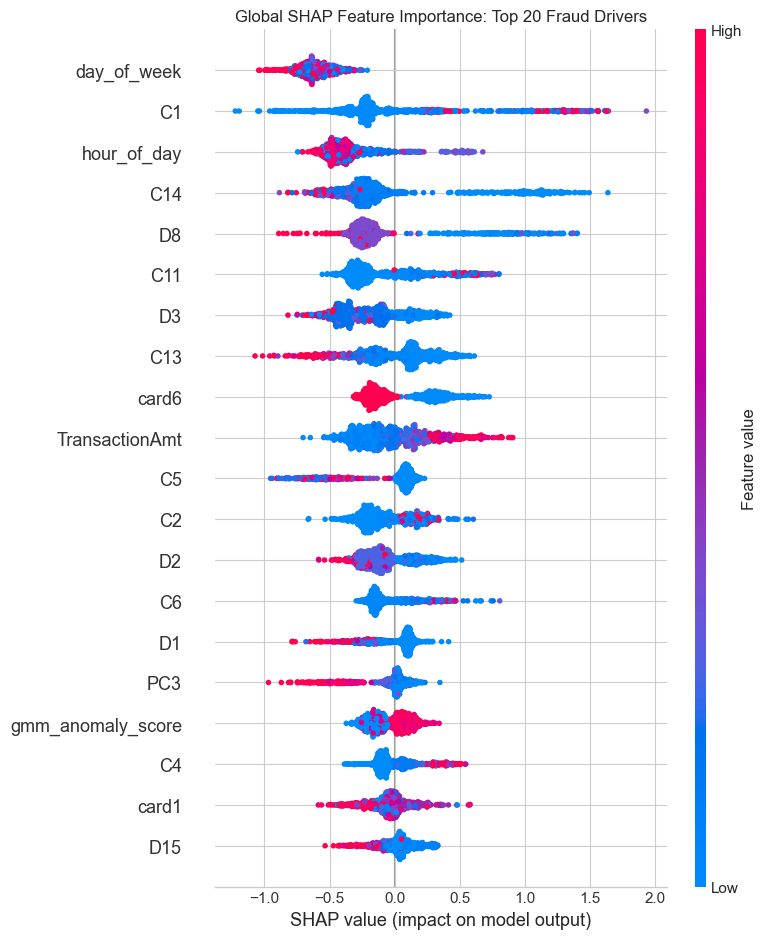

,mean |SHAP value|
day_of_week,0.606133
C1,0.397036
hour_of_day,0.390797
C14,0.384917
D8,0.335520
C11,0.263391
D3,0.262530
C13,0.241547
card6,0.222285
TransactionAmt,0.217215


Saved global SHAP plot and compressed SHAP values.


In [3]:
fraud_sample = X_test.loc[y_test.eq(1)]
legit_sample = X_test.loc[y_test.eq(0)]
n_fraud = min(len(fraud_sample), SHAP_SAMPLE_SIZE // 2)
n_legit = min(len(legit_sample), SHAP_SAMPLE_SIZE - n_fraud)
X_shap = pd.concat([
    fraud_sample.sample(n=n_fraud, random_state=RANDOM_STATE),
    legit_sample.sample(n=n_legit, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_shap)
np.savez_compressed(ARTIFACT_DIR / 'global_shap_values.npz',
                    values=shap_values.values, base_values=shap_values.base_values,
                    data=X_shap.to_numpy(), feature_names=np.asarray(X_shap.columns))

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values.values, X_shap, max_display=20, show=False)
plt.title('Global SHAP Feature Importance: Top 20 Fraud Drivers')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'global_shap_summary_top20.png', dpi=220, bbox_inches='tight')
plt.show()

global_importance = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
display(global_importance.head(20).rename('mean |SHAP value|').to_frame())
print('Saved global SHAP plot and compressed SHAP values.')

### 4. Local SHAP: Three Decision Waterfalls

The local cases are selected deterministically from the untouched test set: a genuine high-confidence fraud, a borderline prediction nearest 0.50 (falling back to 0.40–0.60), and an alert that was actually legitimate. The explanations below are generated from the largest SHAP contributors, so they always match the saved model and selected cases.

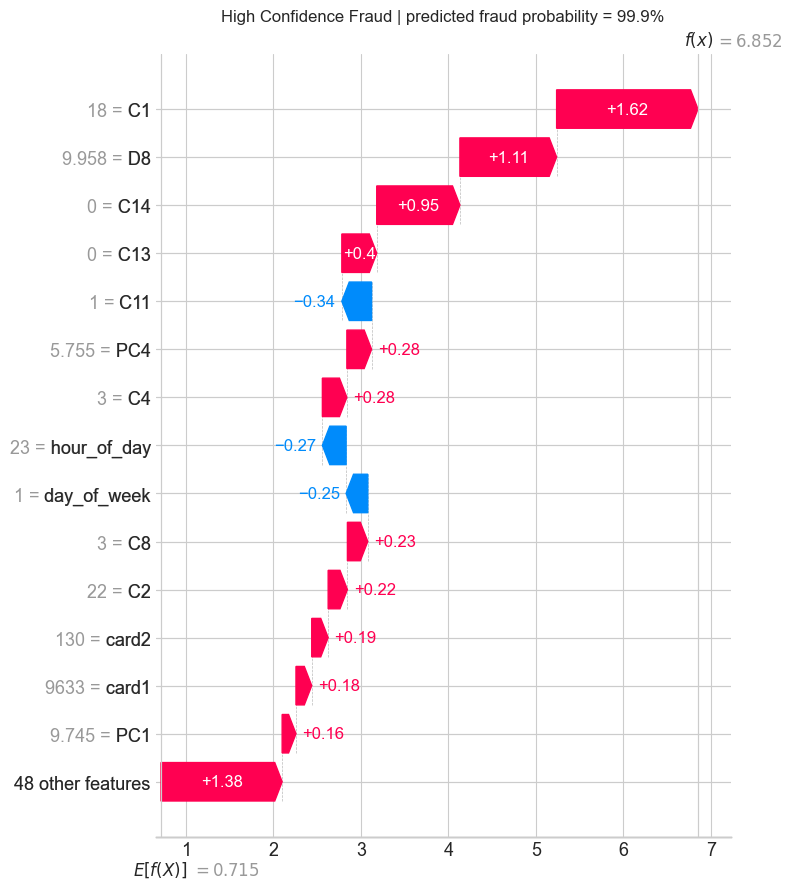

This transaction was flagged for review at the 0.0536 threshold with a 99.9% fraud probability. Its actual label is **fraud**. The strongest drivers were: C1 (18) increased the fraud score; D8 (9.96) increased the fraud score; C14 (0) increased the fraud score; C13 (0) increased the fraud score. Countervailing evidence: no negative drivers among the top contributors. In plain English, the model combined these risk signals and protective signals to reach this score; SHAP explains the model's behavior, not a causal reason for the transaction.

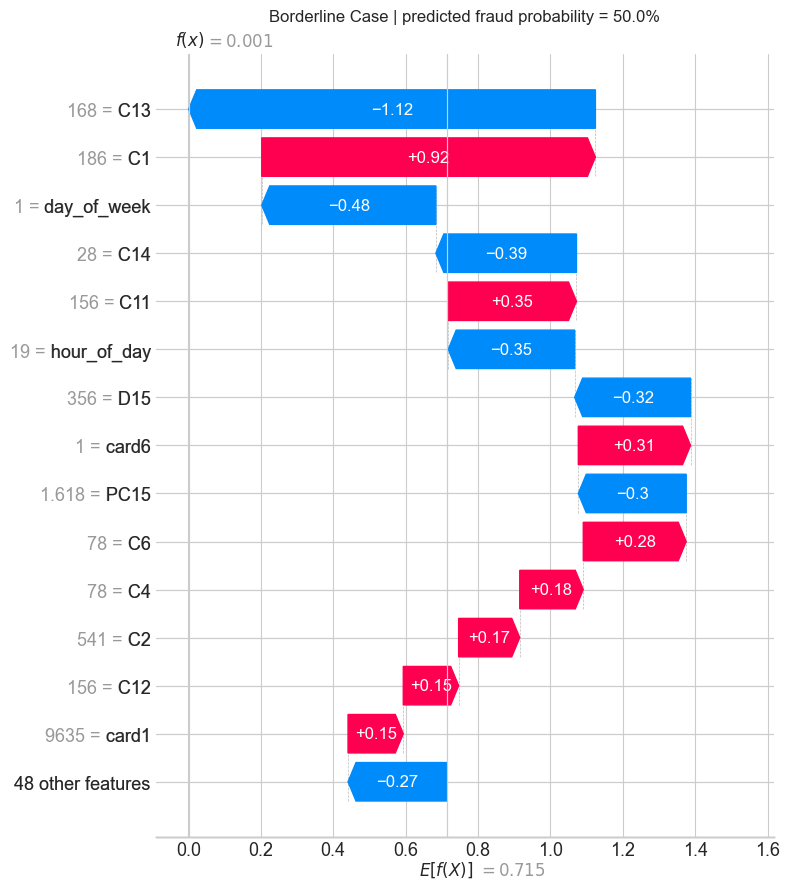

This transaction was flagged for review at the 0.0536 threshold with a 50.0% fraud probability. Its actual label is **fraud**. The strongest drivers were: C1 (186) increased the fraud score. Countervailing evidence: C13 (168) reduced the fraud score; day_of_week (1) reduced the fraud score; C14 (28) reduced the fraud score. In plain English, the model combined these risk signals and protective signals to reach this score; SHAP explains the model's behavior, not a causal reason for the transaction.

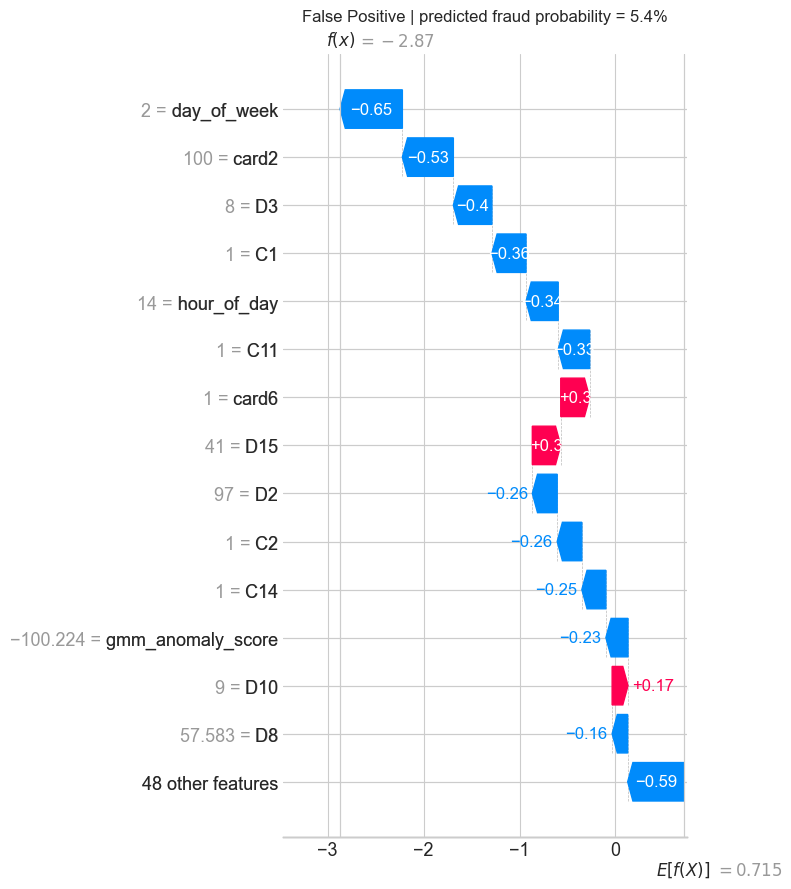

This transaction was flagged for review at the 0.0536 threshold with a 5.4% fraud probability. Its actual label is **legitimate**. The strongest drivers were: no positive drivers among the top contributors. Countervailing evidence: day_of_week (2) reduced the fraud score; card2 (100) reduced the fraud score; D3 (8) reduced the fraud score; C1 (1) reduced the fraud score. In plain English, the model combined these risk signals and protective signals to reach this score; SHAP explains the model's behavior, not a causal reason for the transaction.

,case,test_index,actual_label,probability,decision
0,high_confidence_fraud,547862,fraud,0.998944,flagged for review
1,borderline_case,137438,fraud,0.500290,flagged for review
2,false_positive,548100,legitimate,0.053650,flagged for review


In [4]:
def choose_case(mask, target_probability=None):
    candidates = np.flatnonzero(mask)
    if len(candidates) == 0:
        raise ValueError('No test transaction met the requested case definition.')
    if target_probability is None:
        return candidates[np.argmax(test_proba[candidates])]
    return candidates[np.argmin(np.abs(test_proba[candidates] - target_probability))]

case_positions = {
    'high_confidence_fraud': choose_case((test_proba > 0.90) & (y_test.to_numpy() == 1)),
    'borderline_case': choose_case((test_proba >= 0.40) & (test_proba <= 0.60), target_probability=0.50),
    'false_positive': choose_case((test_proba >= OPERATING_THRESHOLD) & (y_test.to_numpy() == 0), target_probability=OPERATING_THRESHOLD),
}

def feature_sentence(feature, value, contribution):
    direction = 'increased' if contribution > 0 else 'reduced'
    if feature == 'TransactionAmt':
        return f'TransactionAmt (${value:,.2f}) {direction} the fraud score'
    return f'{feature} ({value:.3g}) {direction} the fraud score'

def explain_case(name, position):
    row = X_test.iloc[[position]]
    local_values = explainer(row)
    local = local_values[0]
    contributions = pd.Series(local.values, index=X_test.columns)
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).head(4).index)

    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(local, max_display=15, show=False)
    plt.title(f"{name.replace('_', ' ').title()} | predicted fraud probability = {test_proba[position]:.1%}")
    plt.tight_layout()
    output_path = ARTIFACT_DIR / f'{name}_waterfall.png'
    plt.savefig(output_path, dpi=220, bbox_inches='tight')
    plt.show()

    positive = top[top > 0]
    negative = top[top < 0]
    positive_text = '; '.join(feature_sentence(f, row.iloc[0][f], v) for f, v in positive.items())
    negative_text = '; '.join(feature_sentence(f, row.iloc[0][f], v) for f, v in negative.items())
    actual = 'fraud' if y_test.iloc[position] == 1 else 'legitimate'
    decision = 'flagged for review' if test_pred[position] else 'not flagged'
    paragraph = (f"This transaction was {decision} at the {OPERATING_THRESHOLD:.4f} threshold with a {test_proba[position]:.1%} fraud probability. "
                 f"Its actual label is **{actual}**. The strongest drivers were: {positive_text or 'no positive drivers among the top contributors'}. "
                 f"Countervailing evidence: {negative_text or 'no negative drivers among the top contributors'}. "
                 f"In plain English, the model combined these risk signals and protective signals to reach this score; SHAP explains the model's behavior, not a causal reason for the transaction.")
    display(Markdown(paragraph))
    return {'case': name, 'test_index': X_test.index[position], 'actual_label': actual,
            'probability': test_proba[position], 'decision': decision, 'top_contributors': top.to_dict()}

case_summaries = [explain_case(name, position) for name, position in case_positions.items()]
pd.DataFrame([{k: v for k, v in summary.items() if k != 'top_contributors'} for summary in case_summaries])

### 5. Business Metric Translation

The estimate assumes that the test-set fraud rate and average fraud amount are representative of a future 100,000-transaction day, and that every correctly flagged fraud can be stopped before settlement. It is an operational planning estimate, not a guarantee of recovered loss.

In [5]:
daily_volume = 100_000
expected_fraud_blocked = daily_volume * y_test.mean() * recall
estimated_loss_prevented = expected_fraud_blocked * avg_fraud_amt
business_statement = (
    f'At a decision threshold of {OPERATING_THRESHOLD:.4f}, the model flags {flag_rate:.1%} of transactions for review. '
    f'On a transaction volume of {daily_volume:,}/day, this blocks approximately {expected_fraud_blocked:,.0f} fraudulent transactions before settlement, '
    f'preventing an estimated ${estimated_loss_prevented:,.0f} in losses (at an average fraud transaction value of ${avg_fraud_amt:,.2f}).'
)
display(Markdown(f'**{business_statement}**'))

pd.DataFrame(case_summaries).to_json(ARTIFACT_DIR / 'local_case_summaries.json', orient='records', indent=2)
print('Saved local case metadata and all SHAP artifacts.')

**At a decision threshold of 0.0536, the model flags 28.8% of transactions for review. On a transaction volume of 100,000/day, this blocks approximately 3,190 fraudulent transactions before settlement, preventing an estimated $488,395 in losses (at an average fraud transaction value of $153.09).**

Saved local case metadata and all SHAP artifacts.


### 6. Summary & Controls

- Global SHAP ranks the features that most influenced the saved model across a reproducible test sample.
- The three waterfalls make individual alerts auditable: high-confidence fraud, a borderline decision, and a false positive.
- The plots and compressed SHAP values are saved under `reports/artifacts/shap/` for the README or a Loom walkthrough.
- SHAP is descriptive, not causal. Use it with drift monitoring, analyst feedback, and the performance controls documented in the project guide.